In [349]:
import time,json,os
import numpy as np
import pandas as pd
import scipy.stats
import seaborn as sns
from tqdm.notebook import tqdm
from tqdm.notebook import tqdm_notebook
from common import preprocess,get_csv_files
from warnings import filterwarnings
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine
from scipy.stats import ks_2samp
from scipy.stats import wasserstein_distance
from scipy.stats import stats
from scipy.spatial.distance import pdist
from sklearn.metrics.pairwise import cosine_similarity
filterwarnings("ignore") 
np.set_printoptions(suppress=True)
pd.set_option('display.float_format',lambda x : '%.8f' % x)
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

In [350]:
def show_heatmap(df):
    plt.style.use({'figure.figsize':(16, 6)})
    plt.ticklabel_format(style='plain',axis='both')
    sns.set(font_scale=1.5)
    cmap = sns.cubehelix_palette(start = 1, rot = 3, gamma=0.8, as_cmap = True)
    sns.heatmap(df, cmap = cmap, linewidths = 0.05,annot=False, fmt="g",annot_kws={"fontsize":32})
    #plt.xticks(rotation=60)
    #plt.yticks(rotation=60)
    #font2 = {'family': 'Times New Roman','weight': 'normal','size': 24}
    #plt.xlabel('G2', font2)
    #plt.ylabel('G1', font2)

In [351]:
def get_ent(data):
    """Calculates entropy of the passed `pd.Series`
    """
    p_data = data.value_counts()           # counts occurrence of each value
    entropy = scipy.stats.entropy(p_data)  # get entropy from counts
    return entropy

In [352]:
csv_file = "/data/paper2/sample/0-1-0.csv"
df = pd.read_csv(csv_file,index_col=0)
df_hist,ds_hist = get_histogram(df)
get_ent(ds_hist)

0.7231175376383839

In [353]:
def get_histogram(df , with_preprocess = True):
    if with_preprocess:
        df_tmp = preprocess(df)
    else:
        df_tmp = df.copy( deep = True )
    del df_tmp['label']
    ret_df = pd.DataFrame()
    ret_series = pd.Series()
    for key in df_tmp.keys():
        #hist, bin_edges = np.histogram(df_tmp[key],bins=15*len(df.keys()), density=True)
        hist, bin_edges = np.histogram( df_tmp[key] ,5 * len(df_tmp.keys()) )
        ret_df[key] = pd.Series(hist)
        #cate = pd.qcut( ret_df[key],10,labels=False,duplicates='drop',precision=8)
        #cate.fillna(-1,inplace=True)
        #ret_df[key] = cate
        ret_df[key] = ( ret_df[key] - ret_df[key].min() ) / ( ret_df[key].max()-ret_df[key].min() ) 
        #ret_df[key] = (ret_df[key] - ret_df[key].mean())/ ret_df[key].std()
        #ret_df[key].fillna(-1,inplace=True)
        ret_series = ret_series.append(ret_df[key], ignore_index=True)

    return ret_df.T,ret_series.reset_index(drop=True)

In [354]:
class CJSimilarity(object):
    def __init__(self,list1,list2):
        self.m_list1 = list1
        self.m_list2 = list2
    
    #余弦距离（cosine）
    def Cosine(self):
        ret = cosine_similarity([self.m_list1, self.m_list2])
        return ret[0][1]
        return cosine(self.m_list1, self.m_list2)
    
    #皮尔森相关系数（pearson）,https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html
    def Pearson(self):
        return stats.pearsonr(self.m_list1, self.m_list2)[0]
    
    #欧式距离
    def Euclidean(self):
        return np.linalg.norm(np.array(self.m_list1) - np.array(self.m_list2))

    #KS检验,(P越大，两个分布越相似)
    #P比指定的显著水平（假设为5%）小，则我们完全可以拒绝假设，即两个分布不服从同一分布。
    def KSTest(self):
        ret = ks_2samp(self.m_list1, self.m_list2)
        return ret[0],ret[1]
    
    #EDM距离
    def EDM(self):
        return wasserstein_distance(self.m_list1, self.m_list2)
    
    #Manhattan
    def Manhattan(self):
        return sum(abs(a-b) for a,b in zip(self.m_list1,self.m_list2))
    
    #Minkowski
    def Minkowski(self):
        return float(self.minkowski_distance(np.array(self.m_list1),np.array(self.m_list2),3))
    
    #Jaccard
    def Jaccard(self):
        return self.jaccard_similarity(self.m_list1,self.m_list2)
    
    def minkowski_distance(self,x,y,p_value):
        return self.nth_root(sum(pow(abs(a-b),p_value) for a,b in zip(x, y)),p_value)
    
    def nth_root(self,value, n_root):
        root_value = 1/float(n_root)
        return round (float(value) ** float(root_value),3)
    
    def jaccard_similarity(self,x,y):
        intersection_cardinality = len(set.intersection(*[set(x), set(y)]))
        union_cardinality = len(set.union(*[set(x), set(y)]))
        return intersection_cardinality/float(union_cardinality)
    
    def Entropy(self):
        return abs(get_ent(pd.Series(self.m_list1)) - get_ent(pd.Series(self.m_list2)))

    #def Quadratic(self):
    #    return get_quadratic_distance(self.m_list1,self.m_list2)

In [ ]:
csv_list = []
get_csv_files("/data/paper2/sample/",csv_list)
csv_list.sort()
train_hist = {}
test_hist = {}
print("Calculating histogram...")
bar = tqdm(total=len(csv_list))
for fi in csv_list:
    dataset = os.path.splitext(os.path.basename(fi))[0]
    df = pd.read_csv(fi,index_col=0)
    df_hist,ds_hist = get_histogram(df)
    test_hist[dataset] = {}
    test_hist[dataset]['df_hist'] = df_hist
    test_hist[dataset]['ds_hist'] = ds_hist
    if dataset.split("-")[-1] != '0':
        bar.update(1)
        continue
    train_hist[dataset] = {}
    train_hist[dataset]['df_hist'] = df_hist
    train_hist[dataset]['ds_hist'] = ds_hist
    bar.update(1)

Calculating histogram...


  0%|          | 0/64 [00:00<?, ?it/s]

In [321]:
pd.set_option('display.float_format',lambda x : '%.2f' % x)
df_hist.T

,duration,missed_bytes,src_port,dst_port,src_bytes,dst_bytes,src_pkts,dst_pkts,dst_ip_bytes,conn_state_OTH,...,service_gssapi,service_http,service_irc,service_smb,service_smb;gssapi,service_ssh,service_ssl,proto_icmp,proto_tcp,proto_udp
0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,0.00,1.00,0.00,0.00,0.00,1.00,1.00,1.00,0.41,1.00
1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,0.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
181,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
182,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
183,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [326]:
all_similarity = []
print("Calculating distance ...")
bar = tqdm(total=len(train_hist))
for d1 in train_hist:
    for d2 in test_hist:
        s = CJSimilarity(train_hist[d1]['ds_hist'].tolist(),test_hist[d2]['ds_hist'].tolist())
        tmp = {}
        tmp['G1'] = d1[0:1]
        tmp['G2'] = d2[0:1]
        tmp['D1'] = d1
        tmp['D2'] = d2
        tmp['Cosine'] = s.Cosine()
        tmp['Pearson'] = s.Pearson()
        tmp['Euclidean'] = s.Euclidean()
        tmp['EDM'] = s.EDM()
        tmp['KS'] = s.KSTest()[1]
        tmp['Manhattan'] = s.Manhattan()
        tmp['Minkowski'] = s.Minkowski()
        tmp['Jaccard'] = s.Jaccard()
        tmp['Entropy'] = s.Entropy()
        #tmp['Qaccard'] = s.Quadratic()

        all_similarity.append(tmp)
    bar.update( 1 )
df_similarity = pd.DataFrame(all_similarity)
df_similarity.to_csv("/data/paper2/analyse/similarity.csv")

Calculating distance ...


  0%|          | 0/16 [00:00<?, ?it/s]

G2,0,1,2,3
G1,,,,
0,0.000038,0.001127,0.001593,0.001809
1,0.001137,0.000044,0.000545,0.000712
2,0.001587,0.000546,0.000027,0.000290
3,0.001805,0.000721,0.000281,0.000019


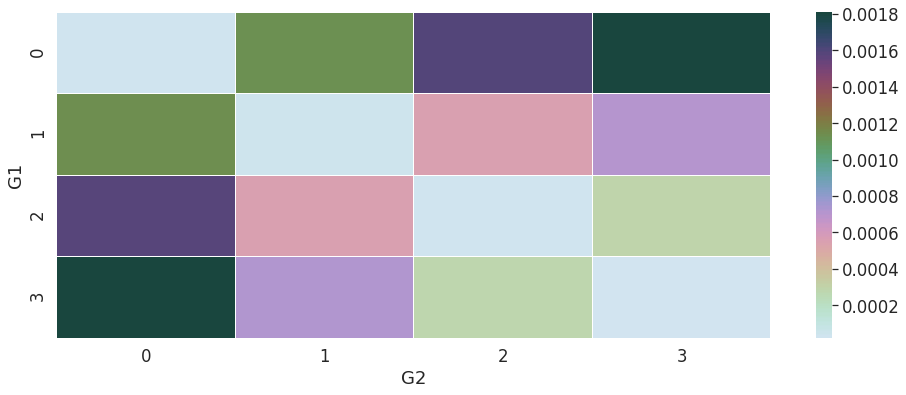

In [327]:
pd.set_option('display.float_format',lambda x : '%.6f' % x)
pt = df_similarity.pivot_table(index='G1', columns='G2',  values='EDM',aggfunc=np.mean)
show_heatmap(pt)
pt

G2,0,1,2,3
G1,,,,
0,0.036882,6.111686,4.650454,4.485876
1,5.919724,2.680057,3.819204,3.932308
2,4.640308,3.936787,1.226517,1.367699
3,4.418829,4.029772,1.209462,0.908453


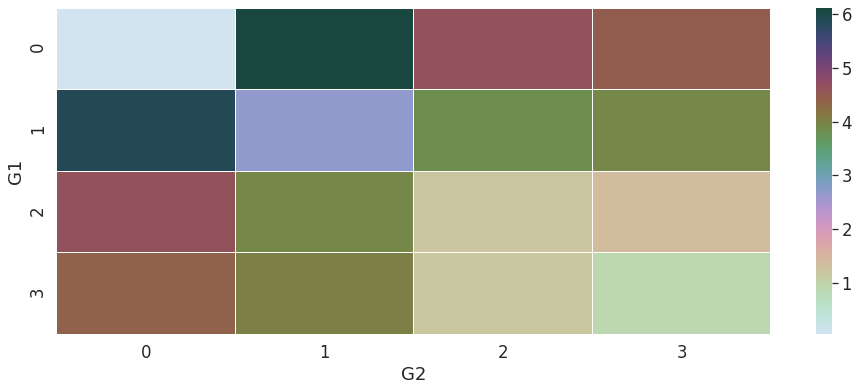

In [328]:
pt = df_similarity.pivot_table(index='G1', columns='G2',  values='Euclidean',aggfunc=np.mean)
show_heatmap(pt)
pt

G2,0,1,2,3
G1,,,,
0,0.999979,0.550986,0.735836,0.753284
1,0.579460,0.903801,0.816150,0.804281
2,0.736946,0.803289,0.973906,0.971526
3,0.760681,0.793004,0.976544,0.982141


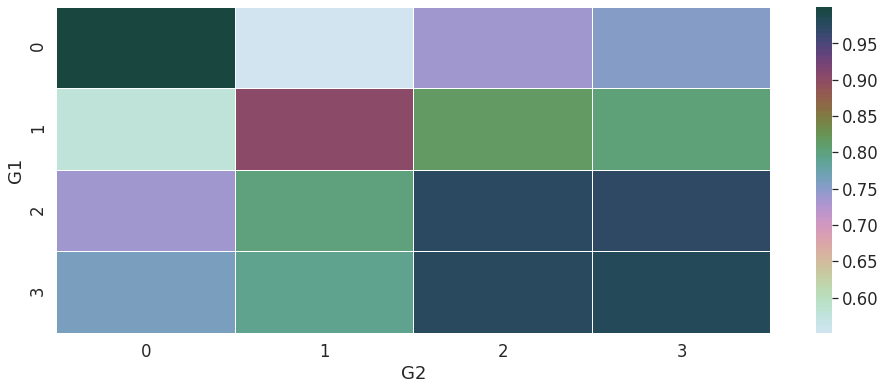

In [329]:
pt = df_similarity.pivot_table(index='G1', columns='G2',  values='Cosine',aggfunc=np.mean)
show_heatmap(pt)
pt

G2,0,1,2,3
G1,,,,
0,0.999978,0.546615,0.733434,0.751157
1,0.575379,0.902965,0.814620,0.802715
2,0.734551,0.801648,0.973696,0.971308
3,0.758621,0.791343,0.976365,0.982006


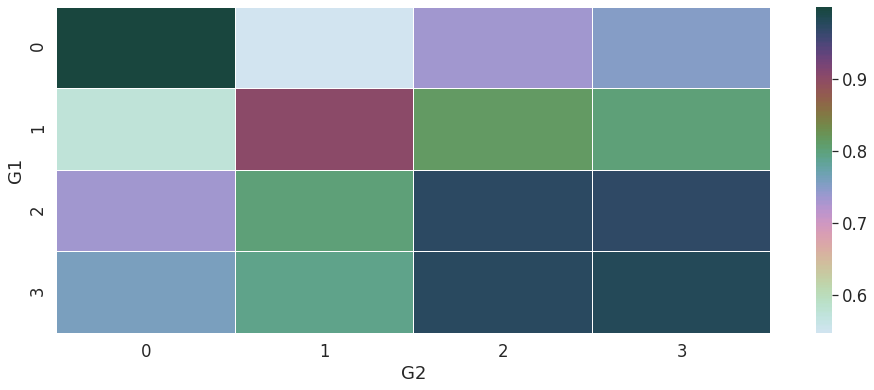

In [330]:
pt = df_similarity.pivot_table(index='G1', columns='G2',  values='Pearson',aggfunc=np.mean)
show_heatmap(pt)
pt

G2,0,1,2,3
G1,,,,
0,0.362883,59.639554,41.816612,38.718074
1,57.188433,8.264616,20.095950,22.258489
2,41.749476,21.208349,2.451460,4.890556
3,38.123896,23.220549,4.403575,1.611862


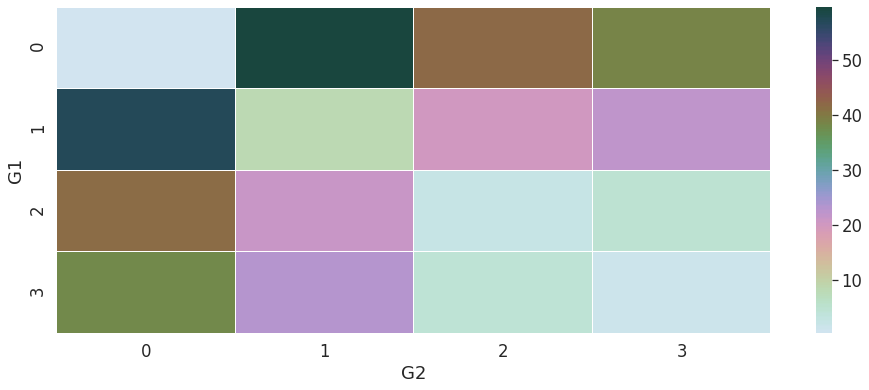

In [331]:
pt = df_similarity.pivot_table(index='G1', columns='G2',  values='Manhattan',aggfunc=np.mean)
show_heatmap(pt)
pt

G2,0,1,2,3
G1,,,,
0,0.021047,3.191844,2.617687,2.563922
1,3.115781,1.881078,2.381875,2.408047
2,2.612391,2.430094,1.035156,1.100313
3,2.533172,2.447812,0.974031,0.788781


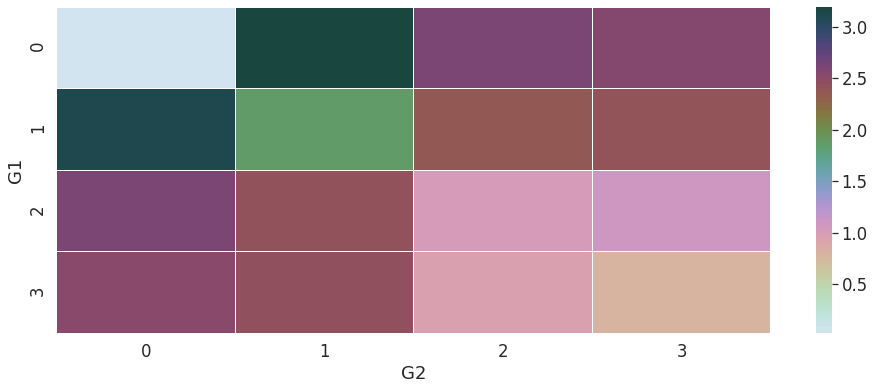

In [332]:
pt = df_similarity.pivot_table(index='G1', columns='G2',  values='Minkowski',aggfunc=np.mean)
show_heatmap(pt)
pt

G2,0,1,2,3
G1,,,,
0,0.065366,0.003749,0.003579,0.003551
1,0.003728,0.066986,0.004404,0.004470
2,0.003630,0.004515,0.066404,0.004232
3,0.003634,0.004632,0.004274,0.066662


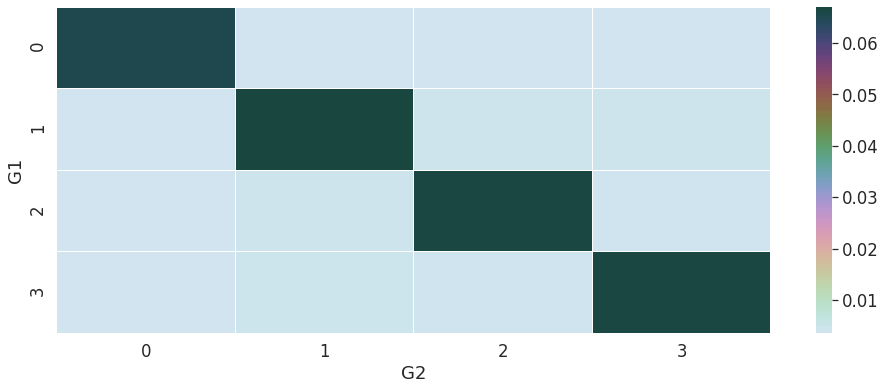

In [333]:
pt = df_similarity.pivot_table(index='G1', columns='G2',  values='Jaccard',aggfunc=np.mean)
show_heatmap(pt)
pt

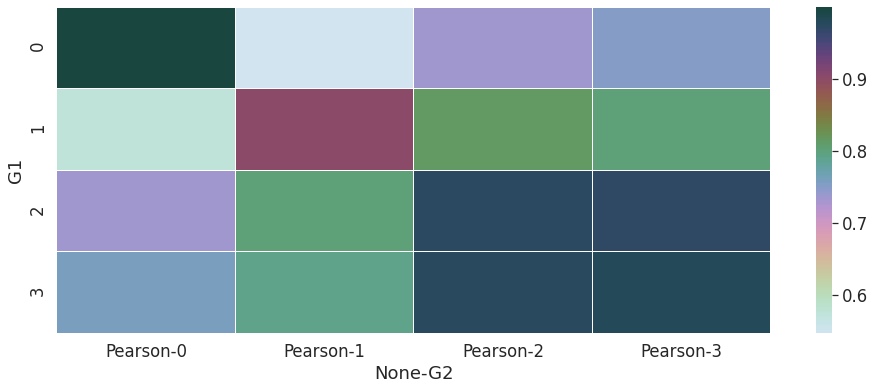

In [334]:
pt = df_similarity.pivot_table(index='G1', columns=['G2'],  values=['Pearson'],aggfunc=np.mean)
show_heatmap(pt)

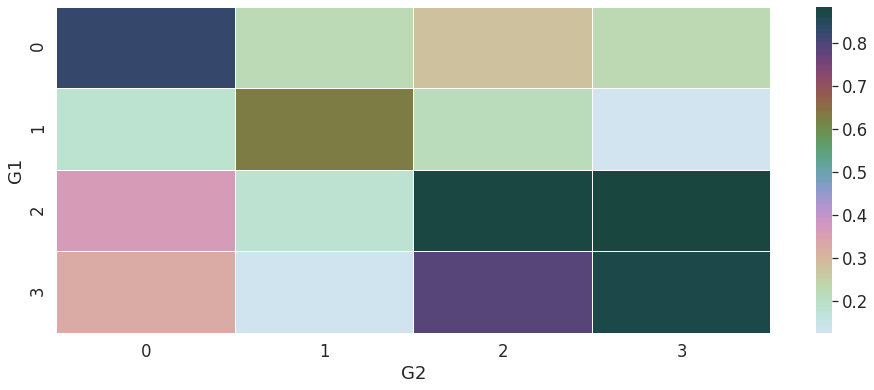

In [335]:
pt = df_similarity.pivot_table(index='G1', columns='G2',  values='KS',aggfunc=np.mean)
show_heatmap(pt)

G2,0,1,2,3
G1,,,,
0,0.054461,0.082747,0.065851,0.071553
1,0.040851,0.068504,0.048296,0.050451
2,0.063536,0.079322,0.054724,0.048423
3,0.068905,0.075425,0.050604,0.030458


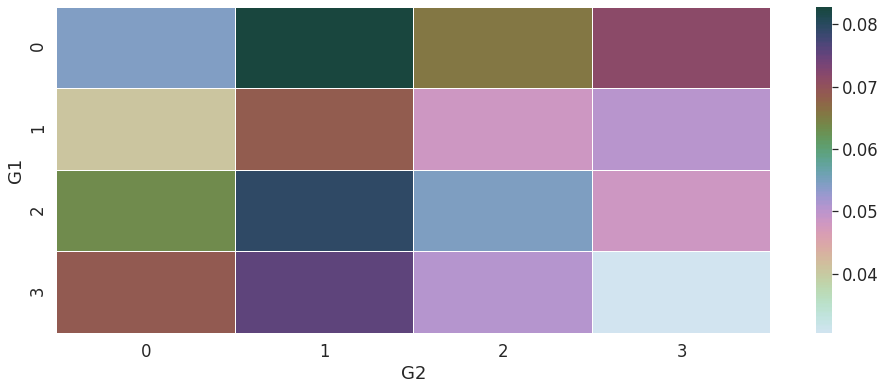

In [339]:
pt = df_similarity.pivot_table(index='G1', columns='G2',  values='Entropy',aggfunc=np.mean)
show_heatmap(pt)
pt

In [336]:
import numpy as np

data=['a','b','c','a','a','b']
data1=np.array(data)
#计算信息熵的方法
def calc_ent(x):
    """
        calculate shanno ent of x
    """

    x_value_list = set([x[i] for i in range(x.shape[0])])
    ent = 0.0
    for x_value in x_value_list:
        p = float(x[x == x_value].shape[0]) / x.shape[0]
        logp = np.log2(p)
        ent -= p * logp

    print (ent)
calc_ent(data1) 

1.4591479170272448
